# Лабораторная 3

Датасет: MNIST.

План:
1. MLP с ReLU и регуляризацией
2. MLP без регуляризации
3. MLP с Sigmoid
4. CNN и визуализация активаций

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [3]:
transform = transforms.ToTensor()

full_train = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_set = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_size = 50000
val_size = 10000
train_set, val_set = random_split(full_train, [train_size, val_size], generator=torch.Generator().manual_seed(seed))

batch_size = 128
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

len(train_set), len(val_set), len(test_set)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.28MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 152kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.51MB/s]


(50000, 10000, 10000)

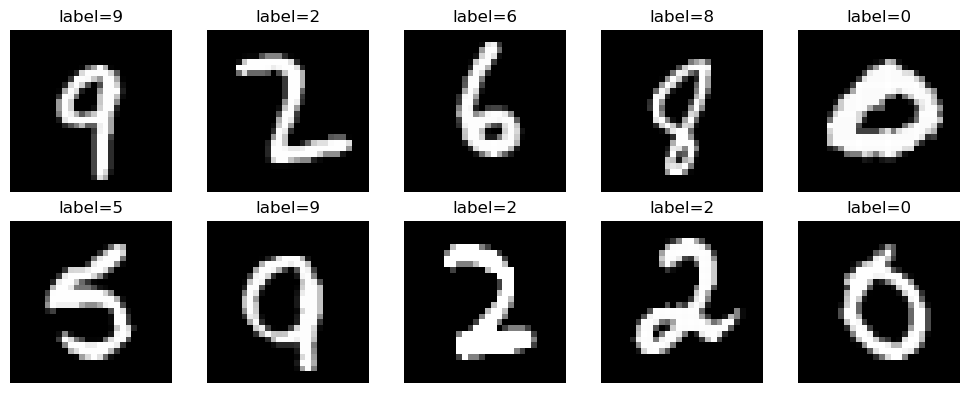

In [4]:
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i].squeeze(0), cmap='gray')
    ax.set_title(f'label={labels[i].item()}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Общие функции обучения и оценки

In [5]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return total_loss / total, correct / total

def train_model(model, train_loader, val_loader, epochs=8, lr=1e-3, weight_decay=0.0):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}")

    return history

## MLP модели

In [6]:
class MLPReLU(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

class MLPSigmoid(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.Sigmoid(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.Sigmoid(),
            nn.Dropout(dropout),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

## 1) Базовая MLP: ReLU + регуляризация

In [7]:
epochs = 8

model_relu_reg = MLPReLU(dropout=0.3).to(device)
hist_relu_reg = train_model(
    model_relu_reg,
    train_loader,
    val_loader,
    epochs=epochs,
    lr=1e-3,
    weight_decay=1e-4
)

Epoch 1/8 | train_loss=0.4599 | val_loss=0.2032 | train_acc=0.8636 | val_acc=0.9382
Epoch 2/8 | train_loss=0.1917 | val_loss=0.1398 | train_acc=0.9427 | val_acc=0.9579
Epoch 3/8 | train_loss=0.1420 | val_loss=0.1179 | train_acc=0.9581 | val_acc=0.9630
Epoch 4/8 | train_loss=0.1145 | val_loss=0.0981 | train_acc=0.9660 | val_acc=0.9695
Epoch 5/8 | train_loss=0.0982 | val_loss=0.0879 | train_acc=0.9696 | val_acc=0.9730
Epoch 6/8 | train_loss=0.0867 | val_loss=0.0867 | train_acc=0.9737 | val_acc=0.9731
Epoch 7/8 | train_loss=0.0785 | val_loss=0.0882 | train_acc=0.9765 | val_acc=0.9731
Epoch 8/8 | train_loss=0.0723 | val_loss=0.0788 | train_acc=0.9775 | val_acc=0.9769


## 2) MLP без регуляризации

In [8]:
model_relu_noreg = MLPReLU(dropout=0.0).to(device)
hist_relu_noreg = train_model(
    model_relu_noreg,
    train_loader,
    val_loader,
    epochs=epochs,
    lr=1e-3,
    weight_decay=0.0
)

Epoch 1/8 | train_loss=0.3797 | val_loss=0.2071 | train_acc=0.8947 | val_acc=0.9383
Epoch 2/8 | train_loss=0.1480 | val_loss=0.1407 | train_acc=0.9556 | val_acc=0.9580
Epoch 3/8 | train_loss=0.0984 | val_loss=0.1082 | train_acc=0.9700 | val_acc=0.9680
Epoch 4/8 | train_loss=0.0705 | val_loss=0.0927 | train_acc=0.9791 | val_acc=0.9718
Epoch 5/8 | train_loss=0.0536 | val_loss=0.0907 | train_acc=0.9831 | val_acc=0.9721
Epoch 6/8 | train_loss=0.0411 | val_loss=0.0911 | train_acc=0.9873 | val_acc=0.9737
Epoch 7/8 | train_loss=0.0320 | val_loss=0.1064 | train_acc=0.9896 | val_acc=0.9693
Epoch 8/8 | train_loss=0.0247 | val_loss=0.0926 | train_acc=0.9921 | val_acc=0.9743


## 3) MLP с Sigmoid

In [9]:
model_sigmoid_reg = MLPSigmoid(dropout=0.3).to(device)
hist_sigmoid_reg = train_model(
    model_sigmoid_reg,
    train_loader,
    val_loader,
    epochs=epochs,
    lr=1e-3,
    weight_decay=1e-4
)

Epoch 1/8 | train_loss=0.9285 | val_loss=0.3663 | train_acc=0.7291 | val_acc=0.8989
Epoch 2/8 | train_loss=0.3461 | val_loss=0.2703 | train_acc=0.9010 | val_acc=0.9207
Epoch 3/8 | train_loss=0.2749 | val_loss=0.2267 | train_acc=0.9200 | val_acc=0.9302
Epoch 4/8 | train_loss=0.2389 | val_loss=0.1954 | train_acc=0.9292 | val_acc=0.9413
Epoch 5/8 | train_loss=0.2125 | val_loss=0.1761 | train_acc=0.9374 | val_acc=0.9470
Epoch 6/8 | train_loss=0.1906 | val_loss=0.1594 | train_acc=0.9435 | val_acc=0.9527
Epoch 7/8 | train_loss=0.1758 | val_loss=0.1481 | train_acc=0.9479 | val_acc=0.9532
Epoch 8/8 | train_loss=0.1657 | val_loss=0.1399 | train_acc=0.9511 | val_acc=0.9571


## Графики сравнения MLP

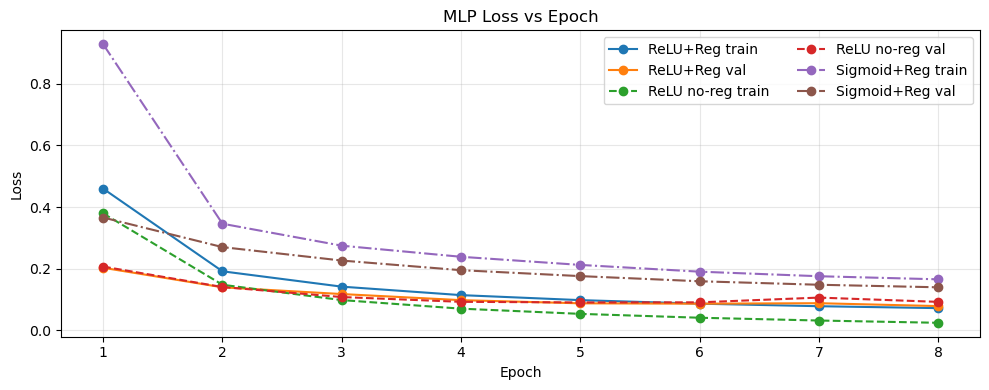

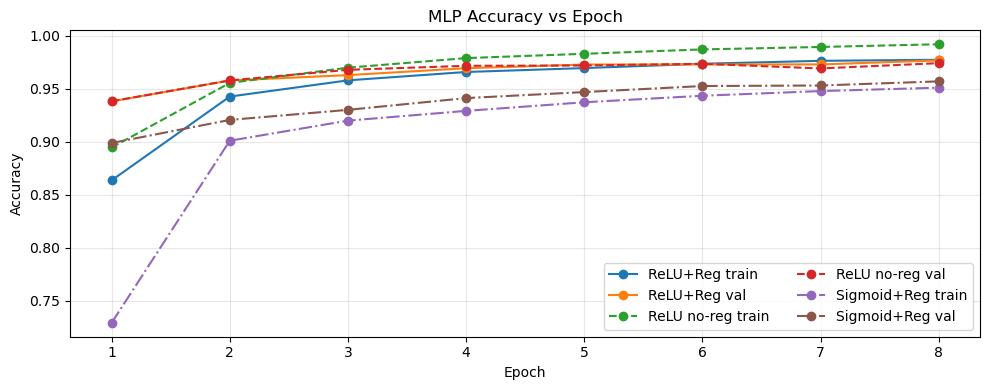

In [16]:
epochs_axis = np.arange(1, epochs + 1)

plt.figure(figsize=(10, 4))
plt.plot(epochs_axis, hist_relu_reg['train_loss'], 'o-', label='ReLU+Reg train')
plt.plot(epochs_axis, hist_relu_reg['val_loss'], 'o-', label='ReLU+Reg val')
plt.plot(epochs_axis, hist_relu_noreg['train_loss'], 'o--', label='ReLU no-reg train')
plt.plot(epochs_axis, hist_relu_noreg['val_loss'], 'o--', label='ReLU no-reg val')
plt.plot(epochs_axis, hist_sigmoid_reg['train_loss'], 'o-.', label='Sigmoid+Reg train')
plt.plot(epochs_axis, hist_sigmoid_reg['val_loss'], 'o-.', label='Sigmoid+Reg val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MLP Loss vs Epoch')
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(epochs_axis, hist_relu_reg['train_acc'], 'o-', label='ReLU+Reg train')
plt.plot(epochs_axis, hist_relu_reg['val_acc'], 'o-', label='ReLU+Reg val')
plt.plot(epochs_axis, hist_relu_noreg['train_acc'], 'o--', label='ReLU no-reg train')
plt.plot(epochs_axis, hist_relu_noreg['val_acc'], 'o--', label='ReLU no-reg val')
plt.plot(epochs_axis, hist_sigmoid_reg['train_acc'], 'o-.', label='Sigmoid+Reg train')
plt.plot(epochs_axis, hist_sigmoid_reg['val_acc'], 'o-.', label='Sigmoid+Reg val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('MLP Accuracy vs Epoch')
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

In [17]:
criterion = nn.CrossEntropyLoss()

test_relu_reg = evaluate(model_relu_reg, test_loader, criterion)[1]
test_relu_noreg = evaluate(model_relu_noreg, test_loader, criterion)[1]
test_sigmoid_reg = evaluate(model_sigmoid_reg, test_loader, criterion)[1]

results_mlp = {
    'ReLU + regularization': test_relu_reg,
    'ReLU without regularization': test_relu_noreg,
    'Sigmoid + regularization': test_sigmoid_reg,
}

for name, score in results_mlp.items():
    print(f'{name} test_acc: {score:.4f}')

best_name = max(results_mlp, key=results_mlp.get)
print(f'\nBest MLP on test: {best_name} ({results_mlp[best_name]:.4f})')

ReLU + regularization test_acc: 0.9803
ReLU without regularization test_acc: 0.9762
Sigmoid + regularization test_acc: 0.9631

Best MLP on test: ReLU + regularization (0.9803)


## Простая CNN

In [12]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [13]:
cnn_epochs = 6
cnn_model = SimpleCNN().to(device)
hist_cnn = train_model(cnn_model, train_loader, val_loader, epochs=cnn_epochs, lr=1e-3, weight_decay=1e-4)
cnn_test_acc = evaluate(cnn_model, test_loader, nn.CrossEntropyLoss())[1]
print(f'CNN test_acc: {cnn_test_acc:.4f}')

Epoch 1/6 | train_loss=0.3729 | val_loss=0.1417 | train_acc=0.8937 | val_acc=0.9599
Epoch 2/6 | train_loss=0.0894 | val_loss=0.0741 | train_acc=0.9730 | val_acc=0.9776
Epoch 3/6 | train_loss=0.0613 | val_loss=0.0617 | train_acc=0.9818 | val_acc=0.9813
Epoch 4/6 | train_loss=0.0492 | val_loss=0.0561 | train_acc=0.9852 | val_acc=0.9844
Epoch 5/6 | train_loss=0.0405 | val_loss=0.0528 | train_acc=0.9870 | val_acc=0.9841
Epoch 6/6 | train_loss=0.0349 | val_loss=0.0517 | train_acc=0.9891 | val_acc=0.9845
CNN test_acc: 0.9865


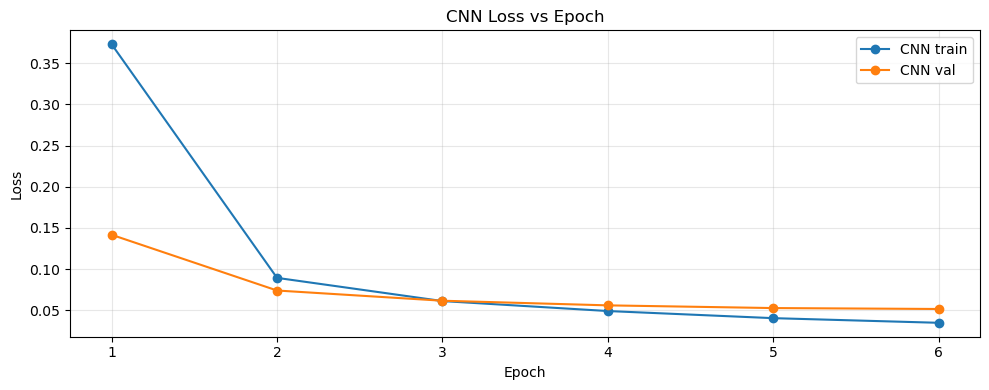

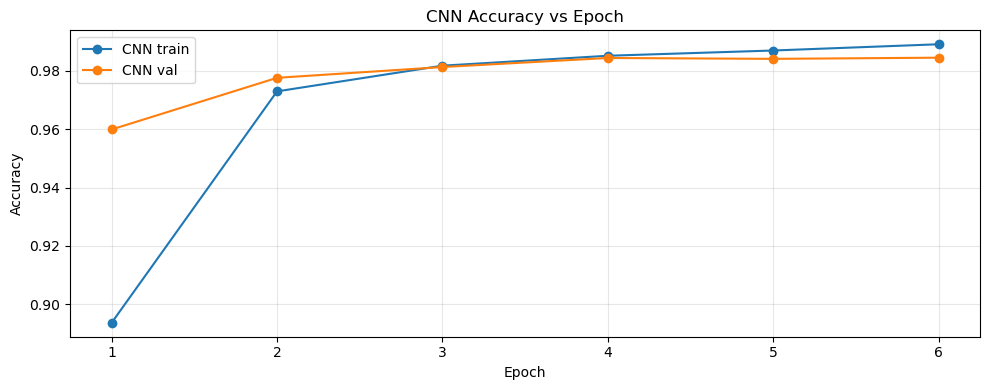

In [14]:
cnn_axis = np.arange(1, cnn_epochs + 1)

plt.figure(figsize=(10, 4))
plt.plot(cnn_axis, hist_cnn['train_loss'], 'o-', label='CNN train')
plt.plot(cnn_axis, hist_cnn['val_loss'], 'o-', label='CNN val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Loss vs Epoch')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(cnn_axis, hist_cnn['train_acc'], 'o-', label='CNN train')
plt.plot(cnn_axis, hist_cnn['val_acc'], 'o-', label='CNN val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy vs Epoch')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Визуализация активаций первых слоёв CNN

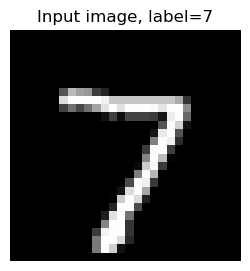

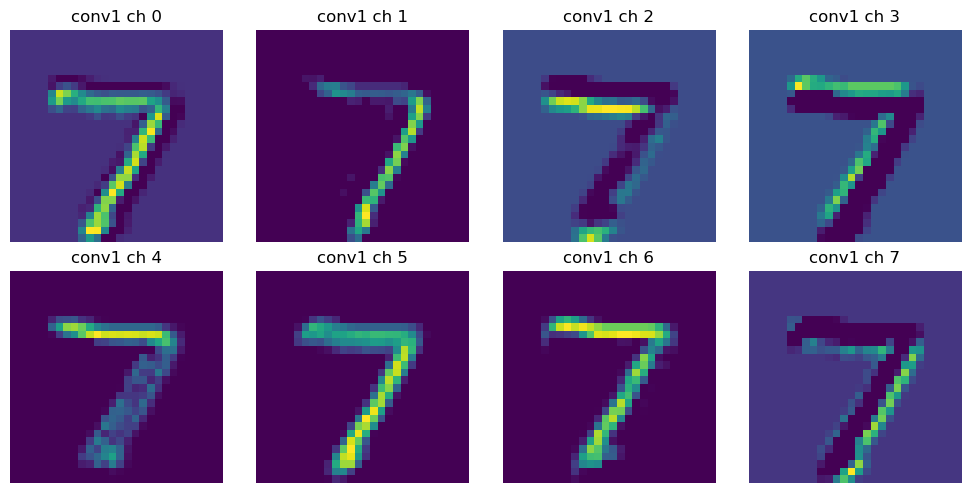

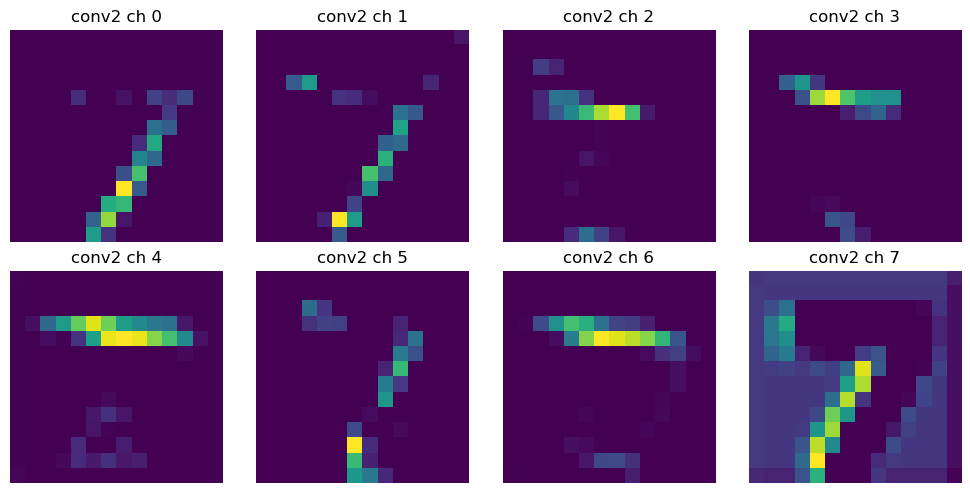

In [15]:
cnn_model.eval()
sample_img, sample_label = test_set[0]
x = sample_img.unsqueeze(0).to(device)

with torch.no_grad():
    act1 = torch.relu(cnn_model.conv1(x)).cpu().squeeze(0)
    act2 = torch.relu(cnn_model.conv2(cnn_model.pool(torch.relu(cnn_model.conv1(x))))).cpu().squeeze(0)

plt.figure(figsize=(3, 3))
plt.imshow(sample_img.squeeze(0), cmap='gray')
plt.title(f'Input image, label={sample_label}')
plt.axis('off')
plt.show()

n_show = 8
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(act1[i], cmap='viridis')
    ax.set_title(f'conv1 ch {i}')
    ax.axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(act2[i], cmap='viridis')
    ax.set_title(f'conv2 ch {i}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Краткие выводы

1. Базовая MLP (ReLU + dropout + weight decay) дала лучший баланс и в этом запуске показала test accuracy **0.9803**.
2. При удалении регуляризации train accuracy выросла заметно сильнее, чем val/test (признак переобучения): test accuracy снизилась до **0.9762**.
3. Замена ReLU на Sigmoid ухудшила качество (test accuracy **0.9631**) и замедлила сходимость. Основная причина — затухание градиента в насыщенных областях сигмоиды.
4. CNN оказалась лучше MLP на MNIST: test accuracy **0.9865**. Свёртки лучше извлекают локальные пространственные признаки изображений.
5. По активациям: на первом сверточном слое видны детекторы простых штрихов и границ (горизонтальные/диагональные линии), на втором — более сложные части цифр (углы, дуги, комбинации штрихов).